Today's topics:
* aggregations: reducing an array to one number
* mean, median, min, max, variance, standard deviation: by hand, then with NumPy

# What is the yield strength of a titanium alloy?

A reasonable question with no single answer. Titanium alloys range from soft,
ductile grades used for chemical piping to very hard ones used for aircraft
fasteners. Yield strength depends on which elements are added and how the alloy
was processed.

Salvador and coworkers (2022) compiled room-temperature mechanical properties
for 283 titanium alloys from 103 papers. Run the cell below; you don't need to
read its code.
([Salvador et al., *Scientific Data* 9, 322](https://doi.org/10.1038/s41597-022-01283-9), CC BY 4.0)

In [1]:
#@title Load the Ti-alloy dataset (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import numpy as np
import pandas as pd

_file = 'biomaterials_ti_alloys.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}',
                 f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    _table = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

_ys = _table.dropna(subset=['YS_MPa'])
alloy = _ys['eid'].to_numpy()
yield_strength = _ys['YS_MPa'].to_numpy()

_ym = _table.dropna(subset=['YM_GPa'])
alloy_modulus = _ym['eid'].to_numpy()
modulus = _ym['YM_GPa'].to_numpy()

uts = _table['UTS_MPa'].dropna().to_numpy()
hardness_hv = _table['HV'].dropna().to_numpy()

print(f'Loaded {len(_table)} titanium alloys from {_file}')
print(f'  yield_strength: {len(yield_strength)} values (MPa)')
print(f'  modulus:        {len(modulus)} values (GPa)')
print(f'  uts:            {len(uts)} values (MPa)')
print(f'  hardness_hv:    {len(hardness_hv)} values (Vickers)')

Loaded 283 titanium alloys from biomaterials_ti_alloys.csv
  yield_strength: 271 values (MPa)
  modulus:        237 values (GPa)
  uts:            197 values (MPa)
  hardness_hv:    152 values (Vickers)


271 alloys have a reported yield strength. Here they are:

In [2]:
print(yield_strength)

[ 782.   735.   672.  1011.   765.  1027.   477.   496.   604.   672.
  695.   715.   348.   606.   625.   629.   740.  1250.  1360.   650.
  537.   511.   441.   810.   782.   729.   682.   501.   780.   553.
 1038.   665.  1107.   932.   953.   936.   754.7  130.   600.   499.
  566.   533.   806.   361.   897.   760.   800.   396.   441.   379.
  373.   376.   444.   257.   557.   213.   599.   432.   367.   501.
 1137.  1078.   636.   731.   823.   862.   972.  1062.  1152.   535.
  588.   711.  1181.  1299.  1421.  1553.  1399.  1068.   499.1  369.
  406.   439.   530.   551.   964.   480.  1560.  1103.  1050.  1143.
 1079.  1016.  1008.   829.   804.   750.  1710.   740.   690.   955.
 1065.   203.   301.   575.   509.   200.   200.   558.   744.   962.
  628.   822.   893.   655.   818.   906.   734.   854.   930.   170.
  275.   380.   483.  1847.  1785.  1539.  1144.  1010.   985.  1049.
 1130.  1239.  1113.  1210.  1287.   784.  1097.   947.   922.   941.
 1023.   927.   980.

Values in MPa. Some near 100, some near 2000. Somewhere in there is the answer
to "what is the yield strength of a titanium alloy," but nobody can read it off
271 numbers.

This is the situation almost every measurement puts us in. We have a
distribution of values, and we need to describe it with a few numbers. Reducing
an array to a single number is called an **aggregation**. Today we build the
most common aggregations by hand, then use the NumPy functions that do them
in one call.

# Summing the values

The simplest aggregation is the sum. Python has a built-in `sum`, and NumPy has
`np.sum`. Both add up every element:

In [3]:
import numpy as np

print(sum(yield_strength))
print(np.sum(yield_strength))

196718.19999999998
196718.2


Same answer, apart from the last digit, which is floating-point rounding (L02).
The NumPy version is much faster on large arrays and works on multi-dimensional
arrays with an `axis` argument, so we use `np.sum`.

The sum by itself is rarely interesting. Total yield strength of 271 alloys is
not a physical quantity. Divide by the count and it becomes one.

# Mean: the balance point

$$\bar{x} = \frac{1}{N}\sum_{i=1}^N x_i$$

Add everything up, divide by how many. `len` gives the count:

In [4]:
total = np.sum(yield_strength)
N = len(yield_strength)
mean_by_hand = total / N
print(f'N = {N}')
print(f'mean (by hand): {mean_by_hand:.1f} MPa')

N = 271
mean (by hand): 725.9 MPa


NumPy does the same thing in one call:

In [5]:
print(f'mean (np.mean): {np.mean(yield_strength):.1f} MPa')

mean (np.mean): 725.9 MPa


The mean is the balance point of the data. Picture every value as a weight on
a ruler. The mean is where the fulcrum goes so the ruler balances. Values far
from the center have more leverage, which matters in a moment.

# Minimum and maximum

Two more aggregations, both from L02. The weakest and strongest alloys in the
set:

In [6]:
print(f'min: {np.min(yield_strength):.0f} MPa')
print(f'max: {np.max(yield_strength):.0f} MPa')

min: 130 MPa
max: 1880 MPa


A factor of fourteen between them. Which alloy is the strongest? `np.argmax`
returns the *position* of the maximum instead of its value, and the `alloy`
array is lined up with `yield_strength`, so the same position names the alloy:

In [7]:
strongest = np.argmax(yield_strength)
print(strongest)
print(alloy[strongest])
print(yield_strength[strongest])

270
at_Ti-14Fe-3Sn-3Nb
1880.0


An as-cast Ti-Fe-Sn-Nb alloy from the very last row of the table, at 1880 MPa.
Roughly three times the mean.

# Median: the middle value

The mean is one idea of "center." Another is the value with half the data below
it and half above. Sort the array, then walk to the middle:

In [8]:
sorted_ys = np.sort(yield_strength)
print(sorted_ys[:10])
print(sorted_ys[-10:])

[130. 170. 200. 200. 202. 203. 213. 216. 220. 237.]
[1539. 1553. 1560. 1574. 1600. 1700. 1710. 1785. 1847. 1880.]


271 is odd, so there is a single middle element at position 135 (positions run
from 0 to 270):

In [9]:
median_by_hand = sorted_ys[135]
print(f'median (by hand): {median_by_hand:.1f} MPa')
print(f'median (np.median): {np.median(yield_strength):.1f} MPa')

median (by hand): 663.0 MPa
median (np.median): 663.0 MPa


*Tutorial: even N.* If the count were even, there would be two middle elements.
The median is their average. `np.median` handles both cases; when you do it by
hand, check whether `N` is odd or even before you pick the index.

Mean 726 MPa, median 663 MPa. Not the same. That gap is information about the
shape of the distribution:

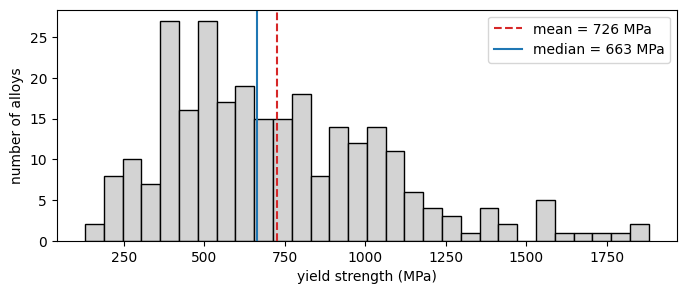

In [10]:
#@title Visualization: histogram of yield strength with mean and median marked (click ▶ to run) { display-mode: "form" }
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(yield_strength, bins=30, color='lightgray', edgecolor='black')
ax.axvline(np.mean(yield_strength), color='C3', linestyle='--', label=f'mean = {np.mean(yield_strength):.0f} MPa')
ax.axvline(np.median(yield_strength), color='C0', linestyle='-', label=f'median = {np.median(yield_strength):.0f} MPa')
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('number of alloys')
ax.legend()
plt.show()

Most alloys sit between 300 and 1000 MPa. A long tail of very strong alloys
stretches out to the right.

Those few high values have a lot of leverage on the balance point, so the mean
is pulled toward the tail. The median only depends on which values are above
and which below, so it stays with the bulk of the data.

This is the general rule. When a distribution has a long tail on one side,
mean and median disagree, and the mean sits on the tail side.

When the tail is a handful of extreme values, the median is the more **robust**
description of the center. When the whole distribution matters, including its
tail, the mean is the one that accounts for every value.

Neither is wrong. They answer different questions.

### [Check your understanding]

The same table has ultimate tensile strength for 197 alloys, in `uts`.

1. Print the number of values, the mean, and the median of `uts`
2. Which is larger, the mean or the median? What does that say about the shape
   of the distribution?
3. Print the min and the max

*Optional challenge*

4. The mean of a set of values is always between the min and the max. Is the
   median? Check with `uts`, then decide whether it has to be true in general.

# Other aggregation functions

NumPy has many more aggregations, and they all work the same way: pass an
array, get one number. Most have a `nan`-safe version that skips missing values
(not today). The ones we use today are marked.

| Function | NaN-safe version | Description | Today |
|---|---|---|---|
| `np.sum` | `np.nansum` | Sum of elements | yes |
| `np.prod` | `np.nanprod` | Product of elements | |
| `np.mean` | `np.nanmean` | Mean of elements | yes |
| `np.std` | `np.nanstd` | Standard deviation | yes |
| `np.var` | `np.nanvar` | Variance | yes |
| `np.min` | `np.nanmin` | Minimum value | yes |
| `np.max` | `np.nanmax` | Maximum value | yes |
| `np.argmin` | `np.nanargmin` | Position of the minimum | yes |
| `np.argmax` | `np.nanargmax` | Position of the maximum | yes |
| `np.median` | `np.nanmedian` | Median | yes |
| `np.percentile` | `np.nanpercentile` | Rank-based statistics | |
| `np.any` | | Is any element true? | |
| `np.all` | | Are all elements true? | |

(Table adapted from VanderPlas, *Python Data Science Handbook*, section 2.4.)

# Variance: how spread out?

We have two centers and two extremes, and nothing yet that describes how wide
the distribution is. The natural starting point: *how far is each alloy from
the mean?* Subtract.

In [11]:
mu = np.mean(yield_strength)
deviations = yield_strength - mu
print(deviations[:10])

[  56.10258303    9.10258303  -53.89741697  285.10258303   39.10258303
  301.10258303 -248.89741697 -229.89741697 -121.89741697  -53.89741697]


Positive for alloys above the mean, negative for alloys below. The obvious
next step is to average these. Let's see what happens:

In [12]:
print(f'mean deviation: {np.mean(deviations):.6f}')

mean deviation: -0.000000


Zero, to the precision of the arithmetic. Not a coincidence. This happens for
every dataset, and it is exactly what "balance point" means: the positive
deviations and the negative deviations cancel.

So the signs have to go. Squaring does it, and it also weights large
deviations more heavily than small ones. Square each deviation, then average:

$$\sigma^2 = \frac{1}{N}\sum_{i=1}^N (x_i - \bar{x})^2$$

That average of squared deviations is the **variance**.

In [13]:
squared_deviations = deviations ** 2
variance_by_hand = np.sum(squared_deviations) / N
print(f'variance (by hand): {variance_by_hand:.0f}')

variance (by hand): 118409


NumPy's `np.var` does the same:

In [14]:
print(f'variance (np.var): {np.var(yield_strength):.0f}')

variance (np.var): 118409


*Tutorial: `ddof`.* `np.var` divides by $N$. A statistics textbook may divide
by $N - 1$ instead. The difference is whether you are *describing* these 271
values (divide by $N$) or *estimating* the spread of the larger population they
were drawn from (divide by $N - 1$, which corrects a small bias). NumPy exposes
this as `ddof`, "delta degrees of freedom":

In [15]:
print(f'variance (ddof=0): {np.var(yield_strength, ddof=0):.0f}')
print(f'variance (ddof=1): {np.var(yield_strength, ddof=1):.0f}')

variance (ddof=0): 118409
variance (ddof=1): 118848


At $N = 271$ the two differ by less than half a percent. At $N = 5$ they
differ by 25%. Decide which convention your problem calls for before you call
the function, and say which one you used when you report the number.

# Standard deviation

The variance of yield strength is about 118,000. In what units? We squared
MPa, so $\mathrm{MPa}^2$, which is not a unit anyone has intuition for. Taking
the square root returns the units to MPa:

$$\sigma = \sqrt{\sigma^2}$$

In [16]:
std_by_hand = np.sqrt(variance_by_hand)
print(f'standard deviation (by hand): {std_by_hand:.1f} MPa')
print(f'standard deviation (np.std):  {np.std(yield_strength):.1f} MPa')

standard deviation (by hand): 344.1 MPa
standard deviation (np.std):  344.1 MPa


So the yield strength of a titanium alloy is 726 MPa, plus or minus 344 MPa.
The second number is as important as the first.

A spread of 344 MPa on a mean of 726 MPa says that "titanium alloy" is not one
material. It is a family, and picking a member of the family matters more than
knowing the average. `np.std` takes `ddof` too, and the same choice applies.

### [Check your understanding]

Variance and standard deviation of a small array by hand, so every step is
visible. Use `small = np.array([2, 4, 4, 6, 9])`. No `np.var` or `np.std`
until step 5.

1. Mean
2. Deviations from the mean
3. Square them, then average. That's the variance
4. `np.sqrt` of the variance. That's the standard deviation
5. Check both against `np.var(small)` and `np.std(small)`

*Optional challenge*

6. Repeat step 5 with `ddof=1`. How big is the gap at $N = 5$, as a percentage?

# Example: stiffness for a bone implant

Every aggregation above, on a different property, answering a real design
question.

Cortical bone has a Young's modulus of roughly 20 GPa. An implant much stiffer
than the bone around it carries most of the load, the bone carries less, and
bone that carries no load resorbs. This is **stress shielding**.

It is a main reason titanium (about 110 GPa for the common Ti-6Al-4V) is
preferred over stainless steel (about 200 GPa) for hip stems. Lower would be
better still.

The dataset has Young's modulus for 237 alloys, in `modulus`, with the aligned
names in `alloy_modulus`.

In [17]:
print(f'N:      {len(modulus)}')
print(f'mean:   {np.mean(modulus):.1f} GPa')
print(f'median: {np.median(modulus):.1f} GPa')
print(f'std:    {np.std(modulus):.1f} GPa')
print(f'min:    {np.min(modulus):.1f} GPa')
print(f'max:    {np.max(modulus):.1f} GPa')

N:      237
mean:   81.9 GPa
median: 78.0 GPa
std:    21.7 GPa
min:    45.0 GPa
max:    157.0 GPa


The typical alloy in this compilation is already well below Ti-6Al-4V, because
the compilation leans toward beta-titanium alloys developed for implants. The
minimum is 45 GPa, closer to bone than to steel. Which alloy?

In [18]:
most_compliant = np.argmin(modulus)
print(alloy_modulus[most_compliant])
print(f'{modulus[most_compliant]:.0f} GPa')

Ti-30Nb-1Mo-4Sn
45 GPa


A Ti-Nb-Mo-Sn alloy at 45 GPa. Mean and median tell us where the family sits.
Standard deviation tells us how much room there is to move within it. Min and
argmin tell us which member to look at first. Five aggregations, five different
facts about the same 237 numbers.

# One number is never enough

We started with 271 yield strengths and no way to talk about them. We now have
a vocabulary: a center (mean or median), a spread (standard deviation), and
the extremes (min and max, and which alloys they belong to). Each aggregation
throws away almost all of the data and keeps one fact about it.

That is the point. The skill is knowing which fact each one keeps.

Report a center without a spread and "titanium alloy" sounds like one
material. Report a spread without a center and there is nothing to anchor it
to. Report the mean when the distribution has a long tail and you have
described the tail as much as the bulk.

## Further reading

- [VanderPlas: Aggregations (min, max, and everything in between)](https://jakevdp.github.io/PythonDataScienceHandbook/02.04-computation-on-arrays-aggregates.html)
- [McKinney: NumPy basics](https://wesmckinney.com/book/numpy-basics) (descriptive statistics section)
- [Salvador et al., *Scientific Data* 9, 322 (2022)](https://doi.org/10.1038/s41597-022-01283-9), the source of today's data